T-Rex running in High Flux mode, with cententral wavelength = 2.00 Å, RRM = 10.
Pulse shaping choppers frequency = 105/-105/-105 Hz, Monochromatic choppers frequency = 140/-140 Hz


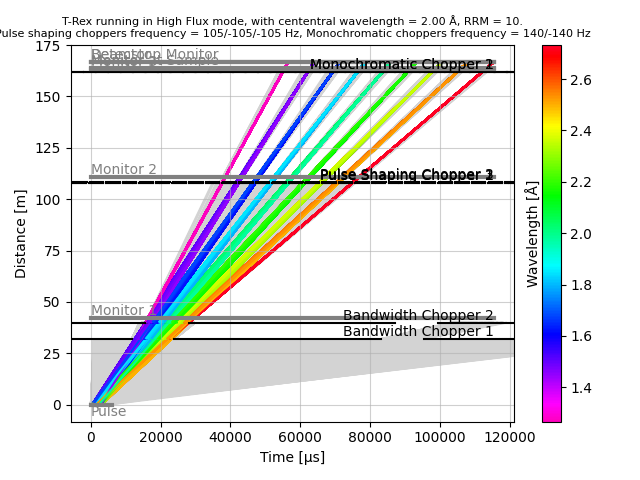

In [1]:
%matplotlib widget
import scipp as sc
from drtrex.instrument import Instrument
from drtrex.components.source import Source
import matplotlib.pyplot as plt

T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(2.0, unit="Å")
rrm: int = 10  # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode


trex = Instrument(wavelength=central_wavelength, rrm=rrm, mode=mode, t_offset=T_OFFSET)
trex.source = Source(facility="ess-trex", neutrons=5_000_000, pulses=1)  # type: ignore
print(trex)
res1 = trex.run()

fig, ax = plt.subplots()
p = res1.plot(visible_rays=1_000_000, blocked_rays=50_000, ax=ax)

ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

# Using a new sources optimized based on the chopper acceptance diagram

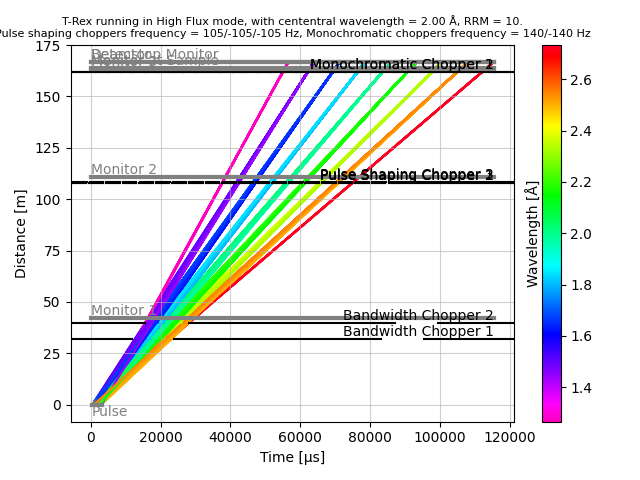

In [2]:
trex.source = Source(
    facility="ess-trex", neutrons=500_000, pulses=1, optimize_for=trex.choppers
)
res2 = trex.run()

fig, ax = plt.subplots()
p = res2.plot(ax=ax)

ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

TypeError: unsupported operand type(s) for /: 'int' and 'NoneType'

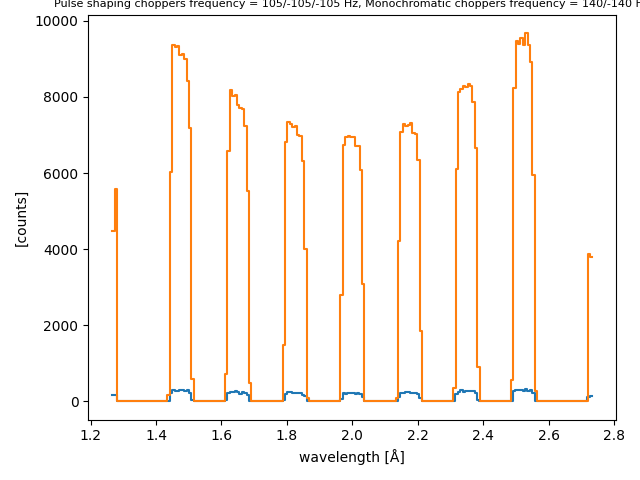

In [3]:
import numpy as np
import plopp as pp

# Squeeze the pulse dimension since we only have one pulse
events_at_sample1 = res1["Monitor at Sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample1 = events_at_sample1[~events_at_sample1.masks["blocked_by_others"]]

# Squeeze the pulse dimension since we only have one pulse
events_at_sample2 = res2["Monitor at Sample"].data.squeeze()
# Remove the events that don't make it to the detector
# events_at_sample2 = events_at_sample2[~events_at_sample2.masks["blocked_by_others"]]

fig, ax = plt.subplots()
events_at_sample1.hist(wavelength=200).plot(ax=ax, c="C0")
events_at_sample2.hist(wavelength=200).plot(ax=ax, c="C1")
ax.set_title("Wavelength at sample position\n" + str(trex), fontsize=8)

delta_lambda = trex.calculate_delta_lambda()
# plot expected Ei wavelength
lambda_i = [trex.wavelength]
for i in range(1, int(trex.rrm / np.max(trex.chopper_slowdown)) // 2 + 1):
    lambda_i.append(trex.wavelength - delta_lambda * i)
    lambda_i.append(trex.wavelength + delta_lambda * i)
# lambda_i = trex.calculate_incoming_wavelength()
lambda_i_bounds_low, lambda_i_bounds_high = trex.calculate_incoming_wavelength_bounds()


for w in lambda_i_bounds_low:
    vline_bw = ax.axvline(x=w.values, c="C2", linestyle="--")
for w in lambda_i_bounds_high:
    vline_bw = ax.axvline(x=w.values, c="C2", linestyle="--")
for lam in lambda_i:
    vline_i = ax.axvline(x=lam.values, c="C3", linestyle="-")

ax.legend([vline_i, vline_bw], ["requested wavelength", "chopper openings"])
ax.set_xlim(min(lambda_i).values, max(lambda_i).values)
ax.grid(alpha=0.6)
fig.tight_layout()

In [ ]:
trex.calculate_ei()

<scipp.Variable> (rrm: 9)    float64            [meV]  [48.235, 37.513, ..., 12.8482, 11.2405]

# Slow down one of the double disc choppers

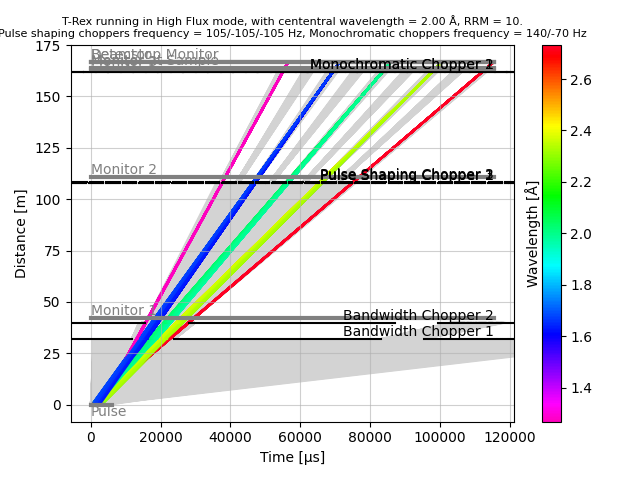

In [6]:
trex = Instrument(
    wavelength=central_wavelength,
    rrm=rrm,
    mode=mode,
    t_offset=T_OFFSET,
    chopper_slowdown=(1, 1, 1, 1, 2),
)
res3 = trex.run()

fig, ax = plt.subplots()
p3 = res3.plot(visible_rays=1_000_000, blocked_rays=50_000, ax=ax)

ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

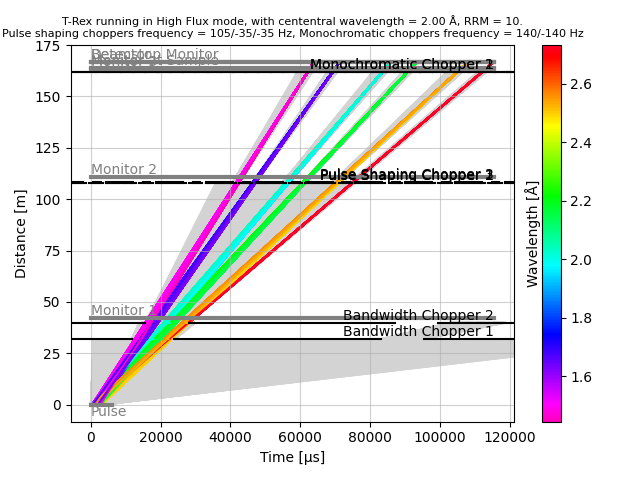

In [7]:
trex = Instrument(
    wavelength=central_wavelength,
    rrm=rrm,
    mode=mode,
    t_offset=T_OFFSET,
    chopper_slowdown=(1, 3, 3, 1, 1),
)
res3 = trex.run()

fig, ax = plt.subplots()
p3 = res3.plot(visible_rays=1_000_000, blocked_rays=50_000, ax=ax)

ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_60240/4263758530.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


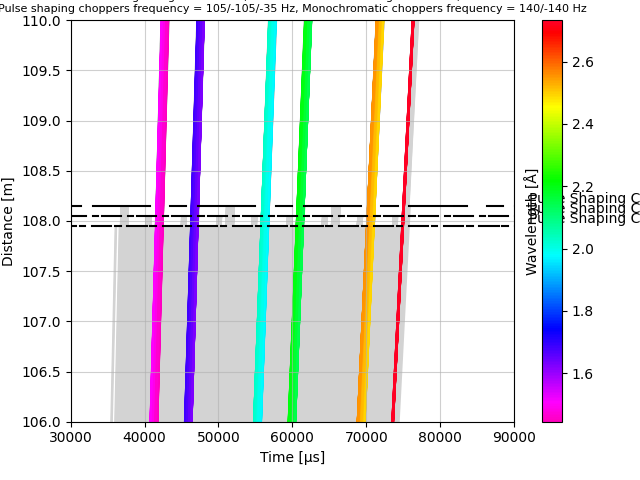

In [ ]:
trex = Instrument(
    wavelength=central_wavelength,
    rrm=rrm,
    mode=mode,
    t_offset=T_OFFSET,
    chopper_slowdown=(1, 1, 3, 1, 1),
)
res3 = trex.run()

fig, ax = plt.subplots()
p3 = res3.plot(visible_rays=1_000_000, blocked_rays=50_000, ax=ax)

ax.set_title(str(trex), fontsize=8)
ax.set_ylim([107.5, 108.5])
ax.set_xlim([30_000, 90_000])
ax.grid(alpha=0.6)
fig.tight_layout()